In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Leer archivos
visits = pd.read_csv('visits_log_us.csv')
orders = pd.read_csv('orders_log_us.csv')
costs = pd.read_csv('costs_us.csv')

visits.info()
orders.info()
print(orders.sample(10))
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
                    Buy Ts  Revenue                   Uid
9894   2017-09-30 22:07:00     4.89  15199180752153663946
40153  2018-03-16 14:54:00    31.17   5815090285204301862
40991  2018-0

In [3]:
# Cambiaré formato snakecase en nombre de columnas
visits.columns = visits.columns.str.lower().str.replace(' ', '_')
orders.columns = orders.columns.str.lower().str.replace(' ','_')
# Cambiaré formato de fecha
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
# Añadiré columna con dia de la semana
visits['day_start'] = visits['start_ts'].dt.day_name()
visits['date_start'] = visits['start_ts'].dt.floor('D')
visits['day_end'] = visits['start_ts'].dt.day_name()
orders['day_buy'] = orders['buy_ts'].dt.day_name()
# Añadiré columna con número de semana
visits['week_start'] = visits['start_ts'].dt.isocalendar().week 
orders['week_buy'] = orders['buy_ts'].dt.isocalendar().week 
# Añadiré columna con numero de mes
visits['month_start'] = visits['start_ts'].dt.month
orders['month_buy'] = orders['buy_ts'].dt.month
# Añadiré columna para la hora redondeada
visits['hour_start'] = visits['start_ts'].dt.floor('h')
visits['hour_end'] = visits['end_ts'].dt.floor('h')
orders['hour_buy'] = orders['buy_ts'].dt.floor('h')

# VISITAS

987.3626373626373


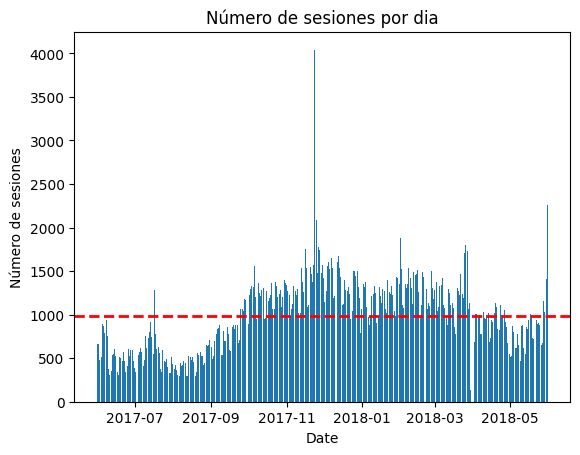

In [4]:
# ¿Cuántas visitas registra la plataforma al día, a la semana, al mes?
visits_per_date = (
    visits
    .groupby('date_start')
    .size()
    .reset_index(name='visits')
)

mean = visits_per_date['visits'].mean()

print(mean)

visits_per_day = (
    visits
    .groupby('day_start')
    .size()
    .reset_index(name='visits')
)
visits_per_week = (
    visits
    .groupby('week_start')
    .size()
    .reset_index(name='visits')
)
visits_per_month = (
    visits
    .groupby('month_start')
    .size()
    .reset_index(name='visits')
)
plt.figure()
plt.bar(visits_per_date['date_start'], visits_per_date['visits'])
plt.axhline(mean, linestyle='--', linewidth=2, color = 'red')
plt.xlabel('Date')
plt.ylabel('Número de sesiones')
plt.title('Número de sesiones por dia')
plt.show()


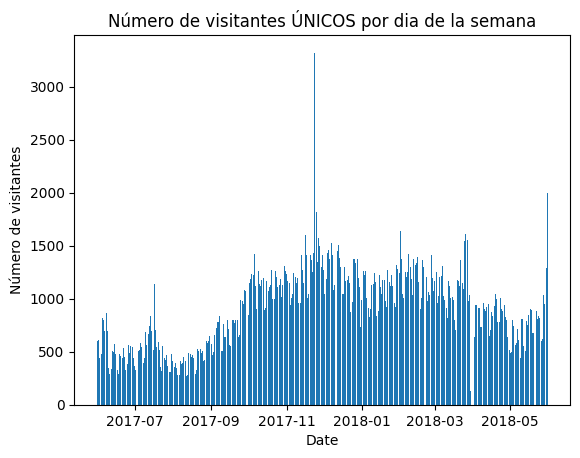

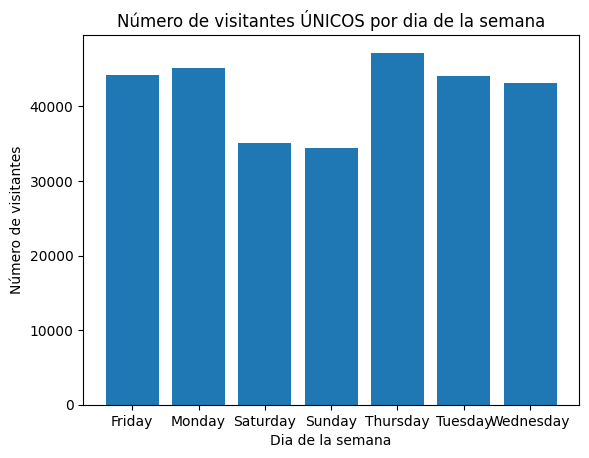

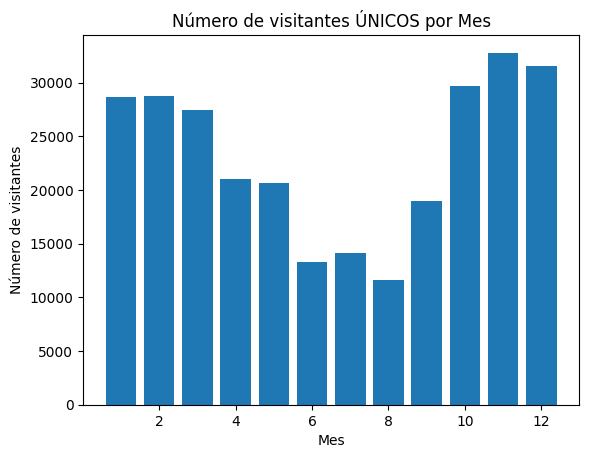

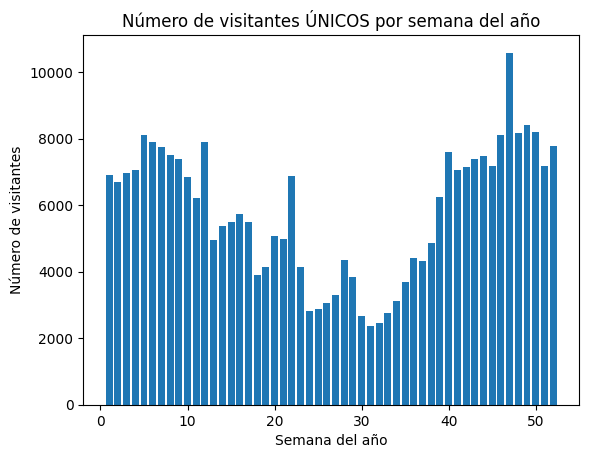

In [5]:
# ¿Cuántos usuarios únicos visitan la página?
usuarios_por_dia = (
    visits
    .groupby('date_start')['uid']
    .nunique()
    .reset_index(name='usuarios_unicos')
)
usuarios_por_dia_semana = (
    visits
    .groupby('day_start')['uid']
    .nunique()
    .reset_index(name='usuarios_unicos')
)
usuarios_por_week = (
    visits
    .groupby('week_start')['uid']
    .nunique()
    .reset_index(name='usuarios_unicos')
)
usuarios_por_month = (
    visits
    .groupby('month_start')['uid']
    .nunique()
    .reset_index(name='usuarios_unicos')
)

plt.figure()
plt.bar(usuarios_por_dia['date_start'], usuarios_por_dia['usuarios_unicos'])
plt.xlabel('Date')
plt.ylabel('Número de visitantes')
plt.title('Número de visitantes ÚNICOS por dia de la semana')
plt.show()

plt.figure()
plt.bar(usuarios_por_dia_semana['day_start'], usuarios_por_dia_semana['usuarios_unicos'])
plt.xlabel('Dia de la semana')
plt.ylabel('Número de visitantes')
plt.title('Número de visitantes ÚNICOS por dia de la semana')
plt.show()

plt.figure()
plt.bar(usuarios_por_month['month_start'], usuarios_por_month['usuarios_unicos'])
plt.xlabel('Mes')
plt.ylabel('Número de visitantes')
plt.title('Número de visitantes ÚNICOS por Mes')
plt.show()

plt.figure()
plt.bar(usuarios_por_week['week_start'], usuarios_por_week['usuarios_unicos'])
plt.xlabel('Semana del año')
plt.ylabel('Número de visitantes')
plt.title('Número de visitantes ÚNICOS por semana del año')
plt.show()

In [6]:
# ¿Cuánto dura la sesión?
visits['time'] = visits['end_ts'] - visits['start_ts']
mean_time = visits['time'].mean()
print(f'En promedio, las sesiones de los usuarios duran {mean_time} minutos')

En promedio, las sesiones de los usuarios duran 0 days 00:10:43.025687256 minutos


En promedio, las sesiones duran 10 minutos con 43 segundos.

In [7]:
# Con qué frecuencia regresan los usuarios?
# Frecuencia % sin unidad de tiempo

# Calculo número de visitas por usuario
visits_per_user = (visits.groupby(['uid']). size().reset_index(name='num_visit'))

total_users = visits['uid'].nunique()

return_visits = visits_per_user[visits_per_user['num_visit']>1]['uid'].nunique()

return_frecuency = (return_visits/total_users)*100
print(return_frecuency)


22.84622363248294


El 22.8% de los visitantes que entrar vuelven al menos una vez durante el tiempo que maneja el dataset.

     num_visit   users
0            1  176041
1            2   30926
2            3   10184
3            4    4357
4            5    2283
..         ...     ...
140        343       1
141        357       1
142        551       1
143        615       1
144        893       1

[145 rows x 2 columns]


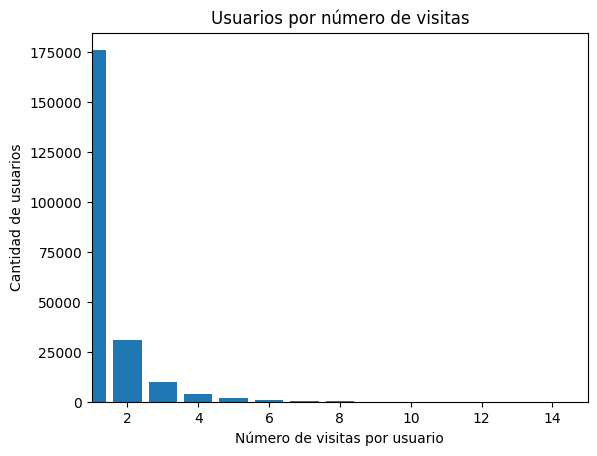

In [8]:
# Con qué frecuencia regresan los usuarios?
# Distribución del número de visitas
distribution = (visits_per_user.groupby('num_visit').size().reset_index(name='users'))
print(distribution)
# Grafico la distribución mediante grafico de barras
plt.figure()
plt.bar(distribution['num_visit'], distribution['users'])
plt.xlabel('Número de visitas por usuario')
plt.ylabel('Cantidad de usuarios')
plt.title('Usuarios por número de visitas')
plt.xlim(1, 15)   # opcional: enfocar en las más comunes
plt.show()

# MÉTRICAS DE VANIDAD

In [9]:
# Usuarios activos diarios DAU
DAU_PER_DAY = (visits.groupby('date_start')['uid'].nunique().reset_index(name='DAU'))
dau = DAU_PER_DAY['DAU'].mean()
print(f'En promedio {dau:.0f} usuarios interactuan diariamente en la aplicación')
#Usiarios activos semanales WAU
iso = visits['start_ts'].dt.isocalendar()
visits['yearweek'] = iso.year.astype(str) + '-' + iso.week.astype(str)

WAU_PER_WEEK = (
    visits
    .groupby('yearweek')['uid']
    .nunique()
    .reset_index(name='WAU')
)
wau = WAU_PER_WEEK['WAU'].mean()
print(f'En promedio {wau:.0f} usuarios interactuan semanalmente en la aplicación')
#Usiarios activos menesuales MAU
visits['yearmonth'] = visits['date_start'].dt.strftime('%Y-%m')
MAU_PER_WEEK = (visits.groupby('yearmonth')['uid'].nunique().reset_index(name='MAU'))
mau = MAU_PER_WEEK['MAU'].mean()
print(f'En promedio {mau:.0f} usuarios interactuan mensualmente en la aplicación')
# STICKY FACTOR o factor de adherencia
sf = (dau/mau)*100
print(f'En promedio el {sf:.0f}% de los usuarios mensuales ingresan a la plataforma en un día típico.\nEste 4% indica que una persona entra entre 1 o 2 dias al mes. Como la plataforma es de venta de entradas a eventos,\nes normal pues seguramente los eventos son esporádicos y no se ofertan todos los dias del año')

En promedio 908 usuarios interactuan diariamente en la aplicación
En promedio 5716 usuarios interactuan semanalmente en la aplicación
En promedio 23228 usuarios interactuan mensualmente en la aplicación
En promedio el 4% de los usuarios mensuales ingresan a la plataforma en un día típico.
Este 4% indica que una persona entra entre 1 o 2 dias al mes. Como la plataforma es de venta de entradas a eventos,
es normal pues seguramente los eventos son esporádicos y no se ofertan todos los dias del año


# VENTAS

In [10]:
# primero ordeno el dataframe con respecto al UID y tiempo de registro o compra
visited_sorted = visits.sort_values(['uid', 'start_ts'])
order_sorted = orders.sort_values(['uid', 'buy_ts'])
# Filtro los primeros registros y compras de cada UID
visit_first = visited_sorted.groupby('uid').first().reset_index()
order_first = order_sorted.groupby('uid').first().reset_index()
# Haré un merge entre los archivos de ventas y visitas.
visit_order = visit_first.merge(order_first, on = 'uid', how = 'inner')
visit_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36523 entries, 0 to 36522
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype          
---  ------       --------------  -----          
 0   uid          36523 non-null  uint64         
 1   device       36523 non-null  object         
 2   end_ts       36523 non-null  datetime64[ns] 
 3   source_id    36523 non-null  int64          
 4   start_ts     36523 non-null  datetime64[ns] 
 5   day_start    36523 non-null  object         
 6   date_start   36523 non-null  datetime64[ns] 
 7   day_end      36523 non-null  object         
 8   week_start   36523 non-null  UInt32         
 9   month_start  36523 non-null  int32          
 10  hour_start   36523 non-null  datetime64[ns] 
 11  hour_end     36523 non-null  datetime64[ns] 
 12  time         36523 non-null  timedelta64[ns]
 13  yearweek     36523 non-null  object         
 14  yearmonth    36523 non-null  object         
 15  buy_ts       36523 non-null  datetim

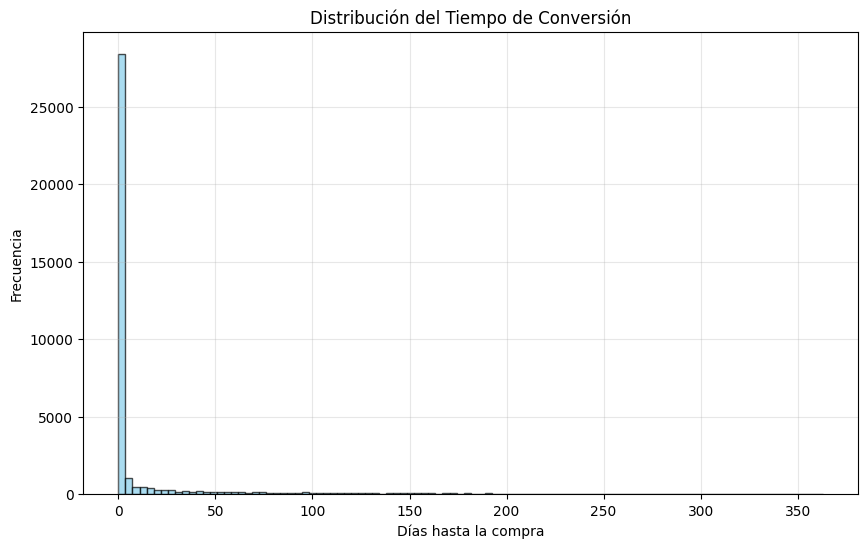

count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: convertion_days, dtype: float64


In [11]:
# Filtro 
# Calculo el tiempo de conversion
visit_order['convertion'] = visit_order['buy_ts'] - visit_order['start_ts']
visit_order['convertion_days'] = visit_order['convertion'].dt.days
visit_order.sample(20)

plt.figure(figsize=(10, 6))
plt.hist(visit_order['convertion_days'].dropna(), bins=100, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribución del Tiempo de Conversión')
plt.xlabel('Días hasta la compra')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

print(visit_order['convertion_days'].describe())

En su mayoría las personas compran el mismo día (el 50%). Sin embargo el promedio toma 17 días para realizar la compra de la entrada. Basado en esto, haré 5 cohortes de análisis: Conversión impulsiva (cero dias), conversión rápida (1,2 dias), conversión corta (2-7 dias), conversión planificada (8, 30) y conversión tardía (más de 30 dias).

In [12]:
# Haré nuevamete merge pero esta vez uniré el data frame de las primeras visitas con la totalidad de ordenes
visit_orders = visit_first.merge(orders, on = 'uid', how = 'right')
visit_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype          
---  ------       --------------  -----          
 0   uid          50415 non-null  uint64         
 1   device       50415 non-null  object         
 2   end_ts       50415 non-null  datetime64[ns] 
 3   source_id    50415 non-null  int64          
 4   start_ts     50415 non-null  datetime64[ns] 
 5   day_start    50415 non-null  object         
 6   date_start   50415 non-null  datetime64[ns] 
 7   day_end      50415 non-null  object         
 8   week_start   50415 non-null  UInt32         
 9   month_start  50415 non-null  int32          
 10  hour_start   50415 non-null  datetime64[ns] 
 11  hour_end     50415 non-null  datetime64[ns] 
 12  time         50415 non-null  timedelta64[ns]
 13  yearweek     50415 non-null  object         
 14  yearmonth    50415 non-null  object         
 15  buy_ts       50415 non-null  datetim

In [13]:
# Ahora haré la clasificación o categorización de las cohortes que analizaré
# defino función
def categorize_conversion_time(days):
    if days == 0:
        return 'Conversión impulsiva'
    elif days <= 2:
        return 'Conversión Rápida'
    elif days <= 7:
        return 'Conversión corta'
    elif days <= 30:
        return 'Conversión planificada'
    else:
        return 'Conversión Tardía'

# Aplicar las categorías
visit_order['cohort'] = visit_order['convertion_days'].apply(categorize_conversion_time)

# Ver la distribución
print(visit_order['cohort'].value_counts())

cohort
Conversión impulsiva      26363
Conversión Tardía          4902
Conversión planificada     2178
Conversión Rápida          1574
Conversión corta           1506
Name: count, dtype: int64


In [14]:
# Para hacer los análisis por cohorte, primero extraeré la cohorte a la que está asociado cada UID para luego pegarlo al dataframe relacionado a las compras
cohort_uid = visit_order[['uid', 'cohort']]
# Ahora lo pegaré con el dataframe original de compras
order_cohort = orders.merge(cohort_uid, on = 'uid', how = 'left')

In [15]:
# Ahora, quisiera saber los ingresos que representa cada cohorte, para ello agruparé por cohorte, sumaré los revenue, y contaré el total de usuarios y compras por cohorte
cohort_grouped = order_cohort.groupby('cohort').agg(
    {'uid': ['count','nunique'], 'revenue': 'sum'}
)
cohort_grouped.columns = ['numero_compras', 'numero_usuarios', 'ingresos']
print(cohort_grouped.info())
print(cohort_grouped)

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, Conversión Rápida to Conversión planificada
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   numero_compras   5 non-null      int64  
 1   numero_usuarios  5 non-null      int64  
 2   ingresos         5 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 160.0+ bytes
None
                        numero_compras  numero_usuarios   ingresos
cohort                                                            
Conversión Rápida                 2618             1574   14259.15
Conversión Tardía                 7163             4902   39431.16
Conversión corta                  2645             1506   12960.37
Conversión impulsiva             34237            26363  156075.98
Conversión planificada            3752             2178   29330.54


In [16]:
# ¿Cuantas compras en promedio tiene los usuario en cada cohorte?
cohort_grouped['número_compras_promedio'] = cohort_grouped['numero_compras']/cohort_grouped['numero_usuarios']
# ¿Cuál es el valor promedio de una compra en cada cohorte?
cohort_grouped['ticket_promedio'] = cohort_grouped['ingresos']/cohort_grouped['numero_compras']
# ¿Cual es el aporte de un cliente promedio en cada cohorte? LTV
cohort_grouped['ltv'] = cohort_grouped['ingresos']/cohort_grouped['numero_usuarios']
print(cohort_grouped)

                        numero_compras  numero_usuarios   ingresos  \
cohort                                                               
Conversión Rápida                 2618             1574   14259.15   
Conversión Tardía                 7163             4902   39431.16   
Conversión corta                  2645             1506   12960.37   
Conversión impulsiva             34237            26363  156075.98   
Conversión planificada            3752             2178   29330.54   

                        número_compras_promedio  ticket_promedio        ltv  
cohort                                                                       
Conversión Rápida                      1.663278         5.446581   9.059180  
Conversión Tardía                      1.461240         5.504839   8.043892  
Conversión corta                       1.756308         4.899951   8.605823  
Conversión impulsiva                   1.298676         4.558693   5.920266  
Conversión planificada                 1.

# MARKETING

                     costo_mes  dias_gasto
source_id yearmonth                       
1         2017-06      1125.61          30
          2017-07      1072.88          31
          2017-08       951.81          31
          2017-09      1502.01          30
          2017-10      2315.75          31
...                        ...         ...
10        2018-01       614.35          31
          2018-02       480.88          28
          2018-03       526.41          30
          2018-04       388.25          29
          2018-05       409.86          31

[84 rows x 2 columns]


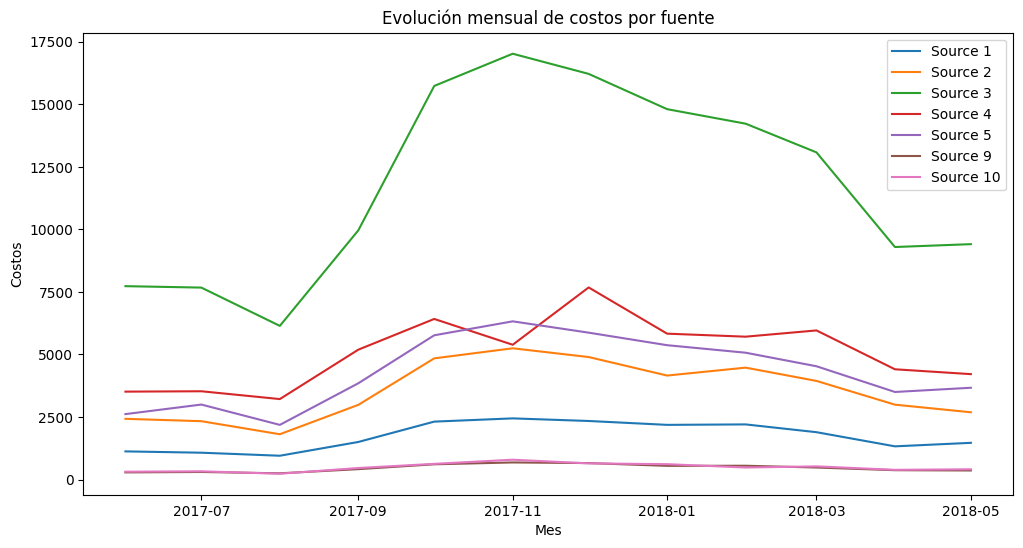

In [17]:
# ¿Cuánto dinero costó cada fuente a lo largo del tiempo?
# Haré el analisis mensual, para ello, primero debo convertir a mes y año cada fecha
costs['dt'] = pd.to_datetime(costs['dt'])
costs['yearmonth'] = costs['dt'].dt.strftime('%Y-%m')
# Ahora agruparé por source y por mes, sumaré los costos mensuales y contaré las fechas de cada mes
source_group = costs.groupby(['source_id', 'yearmonth']).agg(costo_mes = ('costs', 'sum'), dias_gasto=('dt', 'nunique'))
print(source_group)
# Haré una gráfica de serie de tiempo
source_group = source_group.reset_index()
source_group['yearmonth'] = pd.to_datetime(source_group['yearmonth'])
plt.figure(figsize=(12,6))

for source in source_group['source_id'].unique():
    data = source_group[source_group['source_id'] == source]
    plt.plot(data['yearmonth'], data['costo_mes'], label=f'Source {source}')

plt.xlabel('Mes')
plt.ylabel('Costos')
plt.title('Evolución mensual de costos por fuente')
plt.legend()
plt.show()

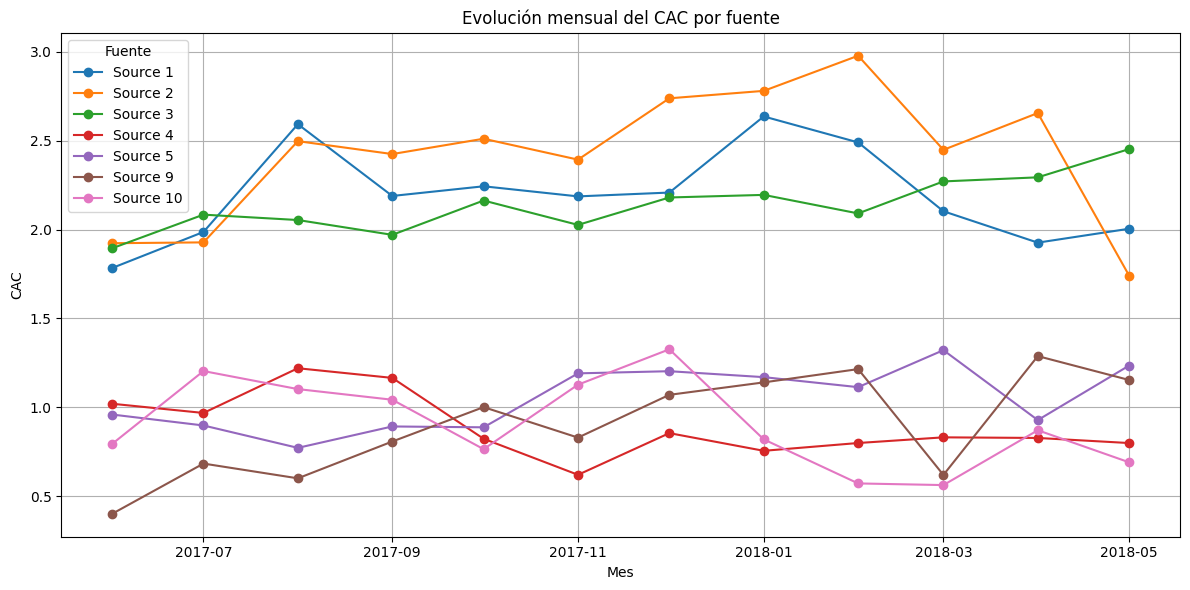

In [18]:
# ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
# Primero crearé una nueva columna que corresponda a mes y año
order_first['yearmonth'] = pd.to_datetime(order_first['buy_ts'])
# Crearé una serie que contenga el source_id de cada uid. Esta información está en el archivo de visitas
visits_sorted = visits.sort_values('start_ts')
user_source = (visits_sorted.groupby('uid').first().reset_index()[['uid', 'source_id', 'yearmonth']])
# Ahora contaré los usuarios por fuente pero por mes-año también
users_per_source_month = (
    user_source
    .groupby(['source_id', 'yearmonth'])
    .agg(total_users=('uid', 'nunique'))
    .reset_index()
)
# Uniré el conteo de usuarios nuevos por mes y por fuente al dataframe de source agrupado
users_per_source_month['yearmonth'] = pd.to_datetime(users_per_source_month['yearmonth'])
costs_users = source_group.merge(users_per_source_month, on = ['source_id', 'yearmonth'], how = 'left')
# Ahora sí puedo calcular CAC costo de adquisición de clientes nuevos
costs_users['cac'] = costs_users['costo_mes']/costs_users['total_users']
costs_users = costs_users[costs_users['total_users'] > 0]

# Grafico el CAC
plt.figure(figsize=(12, 6))

for source in costs_users['source_id'].unique():
    data = costs_users[costs_users['source_id'] == source]
    plt.plot(
        data['yearmonth'],
        data['cac'],
        marker='o',
        label=f'Source {source}'
    )

plt.xlabel('Mes')
plt.ylabel('CAC')
plt.title('Evolución mensual del CAC por fuente')
plt.legend(title='Fuente')
plt.grid(True)
plt.tight_layout()
plt.show()

    source_id  yearmonth  costo_mes  dias_gasto  total_users       cac  \
0           1 2017-06-01    1125.61          30          631  1.783851   
1           1 2017-07-01    1072.88          31          540  1.986815   
2           1 2017-08-01     951.81          31          367  2.593488   
3           1 2017-09-01    1502.01          30          686  2.189519   
4           1 2017-10-01    2315.75          31         1032  2.243944   
..        ...        ...        ...         ...          ...       ...   
79         10 2018-01-01     614.35          31          750  0.819133   
80         10 2018-02-01     480.88          28          842  0.571116   
81         10 2018-03-01     526.41          30          937  0.561804   
82         10 2018-04-01     388.25          29          446  0.870516   
83         10 2018-05-01     409.86          31          594  0.690000   

    ingreso      romi  
0   1378.70  0.224847  
1   1581.68  0.474238  
2   1441.49  0.514472  
3   3071.61  1.

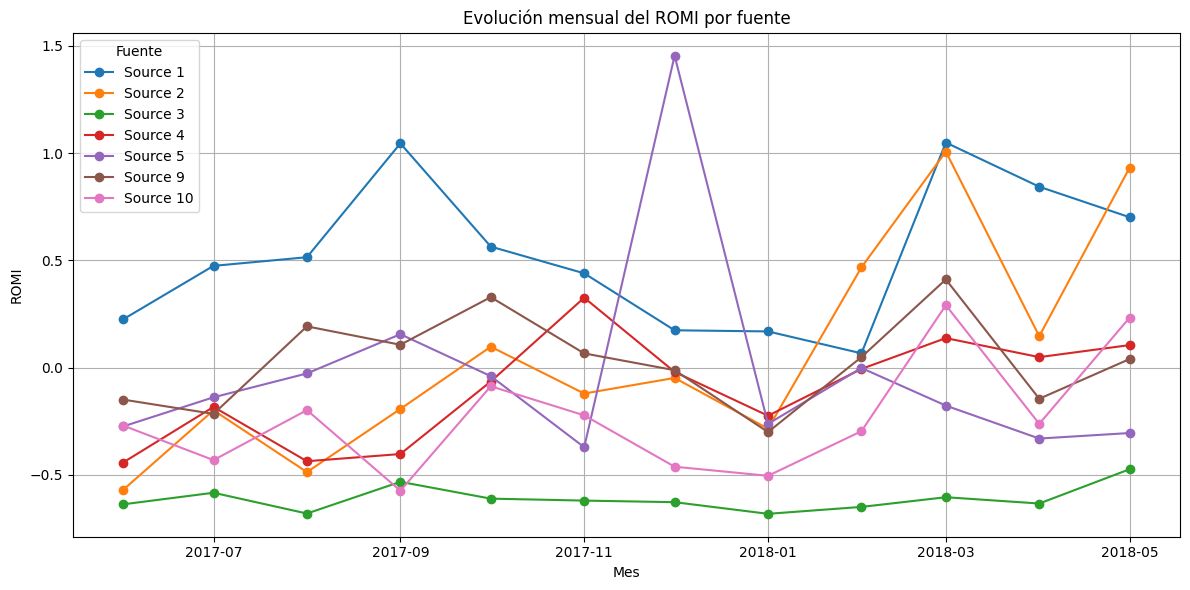

In [19]:
# ROMI
# Agruparé el df orders para conoce las ventas totales mensuales por cada fuente
# añado la informacion del tipo de fuente de cada uid en orders.
users_sources = (visits_sorted.groupby('uid').first().reset_index()[['uid', 'source_id']])
orders_user = orders.merge(users_sources, on = 'uid', how = 'left')
# Creo la variable año-mes
orders_user['yearmonth'] = orders_user['buy_ts'].dt.strftime('%Y-%m')
# Agrupo por mes y por tipo de fuente para conocer los ingresos del mes
revenues_group = (orders_user.groupby(['yearmonth', 'source_id']).agg(ingreso = ('revenue', 'sum')).reset_index())
revenues_group['yearmonth'] = pd.to_datetime(revenues_group['yearmonth'])
# Uniré revenues_group al dataframe de costos mensuales
romi = costs_users.merge(revenues_group, on = (['yearmonth', 'source_id']), how = 'left')
# calcularé el romi ya que tengo los datos necesarios
romi['romi'] = (romi['ingreso']-romi['costo_mes'])/romi['costo_mes']
print(romi)

# Grafico el CAC
plt.figure(figsize=(12, 6))

for source in romi['source_id'].unique():
    data = romi[romi['source_id'] == source]
    plt.plot(
        data['yearmonth'],
        data['romi'],
        marker='o',
        label=f'Source {source}'
    )

plt.xlabel('Mes')
plt.ylabel('ROMI')
plt.title('Evolución mensual del ROMI por fuente')
plt.legend(title='Fuente')
plt.grid(True)
plt.tight_layout()
plt.show()

CONCLUSIONES GENERALES:
1. VENTAS: El análisis del comportamiento de los usuarios muestra que la plataforma tiene un uso coherente con su naturaleza transaccional: solo el 22.8% de los visitantes regresa al menos una vez y la relación DAU/MAU es cercana al 4%, lo que indica que los usuarios ingresan en promedio 1–2 días al mes, algo esperado en una plataforma de venta de entradas a eventos esporádicos. Se observa una fuerte estacionalidad, con una caída en la actividad a mitad de año y un crecimiento marcado hacia el último trimestre, especialmente entre octubre y diciembre, lo que sugiere que los eventos y campañas en estos meses generan picos significativos de tráfico. A nivel semanal, los días con mayor actividad son de lunes a jueves, mientras que los fines de semana presentan menor interacción, lo que indica que los usuarios planifican y compran entradas principalmente en días laborales. En conjunto, los datos reflejan que el crecimiento y el tráfico están impulsados por eventos específicos más que por el uso diario, por lo que la estrategia debería enfocarse en optimizar la conversión, el timing de campañas y la captación de usuarios recurrentes, más que en fomentar un engagement diario continuo.

# CONCLUSIONES GENERALES

Observé que el tráfico y recurrencia de visitantes al portal web es coherente con el tipo de negocio. La métrica más importante para este análisis no es la recurrencia en la página sino la tasa de conversión. 
Al analizar las ventas me di cuenta que la tendencia de los usuarios es la compra impulsiva (el mismo día del registro). El comportamiento más habitual no se explica por las medidas de tendencia central (media 17 días) o de dispersión (std 46 días). Al menos el 50% de los casos compran el día del registro. Un 25% compran durante los sigueintes 2 días y el 25% restante compran en los siguientes meses. A pesar de ser los clientes impulsivos los que representan mayores ingresos para la compañía, son los usuarios con compra planificada los que a largo plazo aportan mayor valor. Para ellos, se podrían implementar estrategias de marketing que les favorezcan y de esta forma estimular sus compras.
En cuanto al análisis de marketing, observamos que no todas las fuentes representaron ganancias para la compañía, de hecho, la fuente 3 la cual fue la más costosa siempre presentó ROMI negativo. La fuente #1 siempre se mantuvo en un umbral positivo y en promedio representa el retorno más valioso.